In [4]:
import os
import json
import pandas as pd

In [5]:
base_path = r"C:\Users\simon\Downloads\archive\negochat"

In [6]:
files = os.listdir(base_path)

print(files[:5])
print(len(files))

['0.json', '1.json', '10.json', '100.json', '101.json']
105


In [7]:
sample_file = os.path.join(base_path, files[0])

with open(sample_file, "r") as f:
    data = json.load(f)

data

{'set': 'train',
 'turns': [{'role': 'Candidate',
   'output': [{'Greet': True}],
   'data': 'Hello. I would like to discuss the issues of my contract.'},
  {'role': 'Candidate',
   'input': 'I would like a position of project manager',
   'output': [{'Offer': {'Job Description': 'Project Manager'}}]},
  {'role': 'Employer',
   'input': 'We do not have any project manager positions open at this time. ',
   'output': [{'Reject': {'Job Description': 'Project Manager'}}]},
  {'role': 'Candidate',
   'input': 'I want a position of project manager',
   'output': [{'Offer': {'Job Description': 'Project Manager'}}]},
  {'role': 'Employer',
   'input': 'I do have programmer positions open with a strong potential to advance to project manager based on your performance.',
   'output': [{'Offer': {'Job Description': 'Programmer'}}]},
  {'role': 'Candidate',
   'input': 'I disagree about a position of programmer. I would like a position of project manager',
   'output': [{'Reject': {'Job Descripti

In [8]:

# LISTA RIGHE
rows = []

# CICLO SU TUTTI I JSON
for filename in os.listdir(base_path):

    if filename.endswith(".json"):

        dialogue_id = filename.replace(".json", "")

        file_path = os.path.join(base_path, filename)

        with open(file_path, "r", encoding="utf-8") as f:
            dialogue = json.load(f)

        split = dialogue.get("set", None)

        turns = dialogue.get("turns", [])

        # CICLO SUI TURNI
        for turn_id, turn in enumerate(turns):

            role = turn.get("role", None)

            # alcuni turni usano "input", altri "data"
            text = turn.get("input") or turn.get("data") or ""

            outputs = turn.get("output", [])

            # CASO 1:
            # nessun dialogue act annotato
            if len(outputs) == 0:

                rows.append({
                    "dialogue_id": dialogue_id,
                    "split": split,
                    "turn_id": turn_id,
                    "role": role,
                    "text": text,
                    "act": "Other",
                    "issue": None,
                    "value": None
                })

            # CASO 2:
            # uno o più dialogue acts
            else:

                for output in outputs:

                    for act, content in output.items():

                        issue = None
                        value = None

                        # esempio:
                        # {"Offer": {"Salary": "120,000 USD"}}

                        if isinstance(content, dict):

                            for issue_name, issue_value in content.items():

                                issue = issue_name
                                value = issue_value

                        # esempio:
                        # {"Accept": True}

                        elif content is True:

                            issue = None
                            value = True

                        rows.append({
                            "dialogue_id": dialogue_id,
                            "split": split,
                            "turn_id": turn_id,
                            "role": role,
                            "text": text,
                            "act": act,
                            "issue": issue,
                            "value": value
                        })

# CREAZIONE DATAFRAME
human_df = pd.DataFrame(rows)

# ORDINAMENTO
human_df = human_df.sort_values(
    by=["dialogue_id", "turn_id"]
).reset_index(drop=True)

# OUTPUT
human_df.head()

,dialogue_id,split,turn_id,role,text,act,issue,value
0,0,train,0,Candidate,Hello. I would like to discuss the issues of m...,Greet,NaN,True
1,0,train,1,Candidate,I would like a position of project manager,Offer,Job Description,Project Manager
2,0,train,2,Employer,We do not have any project manager positions o...,Reject,Job Description,Project Manager
3,0,train,3,Candidate,I want a position of project manager,Offer,Job Description,Project Manager
4,0,train,4,Employer,I do have programmer positions open with a str...,Offer,Job Description,Programmer


In [9]:
human_df.shape


(4993, 8)

In [10]:
human_df.head(20)

,dialogue_id,split,turn_id,role,text,act,issue,value
0,0,train,0,Candidate,Hello. I would like to discuss the issues of m...,Greet,NaN,True
1,0,train,1,Candidate,I would like a position of project manager,Offer,Job Description,Project Manager
2,0,train,2,Employer,We do not have any project manager positions o...,Reject,Job Description,Project Manager
3,0,train,3,Candidate,I want a position of project manager,Offer,Job Description,Project Manager
4,0,train,4,Employer,I do have programmer positions open with a str...,Offer,Job Description,Programmer
5,0,train,5,Candidate,I disagree about a position of programmer. I w...,Reject,Job Description,Programmer
6,0,train,5,Candidate,I disagree about a position of programmer. I w...,Offer,Job Description,Project Manager
7,0,train,6,Employer,I disagree about position of project manager,Reject,Job Description,Project Manager
8,0,train,7,Candidate,I am willing to have a position of team manager,Offer,Job Description,Team Manager
9,0,train,8,Employer,I might consider team manager based on your ot...,Accept,Job Description,Team Manager


Most dialogue acts in Negochat are Offers, reflecting the iterative nature of contractual negotiation. Non-negotiation utterances such as greetings or conversational acknowledgements are represented as “Other” and naturally lack issue-specific annotations.

In [11]:
human_df["act"].value_counts()

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64

In [12]:
human_df["role"].value_counts()

role
Candidate    2967
Employer     2026
Name: count, dtype: int64

In [13]:
human_df["issue"].value_counts()

issue
Working Hours              865
Salary                     852
Job Description            685
Leased Car                 573
Pension Fund               406
Promotion Possibilities    274
Offer                       64
Name: count, dtype: int64

In [14]:
processed_path = r"C:\Users\simon\OneDrive\Desktop\negotiation_arena\data\processed"

os.makedirs(processed_path, exist_ok=True)

human_df.to_csv(
    os.path.join(processed_path, "human_negotiations.csv"),
    index=False
)


In [15]:
human_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4993 entries, 0 to 4992
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   dialogue_id  4993 non-null   str   
 1   split        4993 non-null   str   
 2   turn_id      4993 non-null   int64 
 3   role         4993 non-null   str   
 4   text         4993 non-null   str   
 5   act          4993 non-null   str   
 6   issue        3719 non-null   str   
 7   value        4495 non-null   object
dtypes: int64(1), object(1), str(6)
memory usage: 312.2+ KB


The processed human negotiation dataset contains 4,993 annotated negotiation acts extracted from 105 multi-turn job negotiation dialogues. Each row represents a single negotiation act associated with a dialogue turn, role, utterance text, negotiated issue, and proposed value when available. Missing values in the issue and value fields are expected, since some conversational acts such as greetings, generic acceptances, or conversational acknowledgements do not explicitly refer to negotiable contract attributes.

In [16]:
human_df.head(20)

,dialogue_id,split,turn_id,role,text,act,issue,value
0,0,train,0,Candidate,Hello. I would like to discuss the issues of m...,Greet,NaN,True
1,0,train,1,Candidate,I would like a position of project manager,Offer,Job Description,Project Manager
2,0,train,2,Employer,We do not have any project manager positions o...,Reject,Job Description,Project Manager
3,0,train,3,Candidate,I want a position of project manager,Offer,Job Description,Project Manager
4,0,train,4,Employer,I do have programmer positions open with a str...,Offer,Job Description,Programmer
5,0,train,5,Candidate,I disagree about a position of programmer. I w...,Reject,Job Description,Programmer
6,0,train,5,Candidate,I disagree about a position of programmer. I w...,Offer,Job Description,Project Manager
7,0,train,6,Employer,I disagree about position of project manager,Reject,Job Description,Project Manager
8,0,train,7,Candidate,I am willing to have a position of team manager,Offer,Job Description,Team Manager
9,0,train,8,Employer,I might consider team manager based on your ot...,Accept,Job Description,Team Manager


In [17]:
human_df.isna().sum()

dialogue_id       0
split             0
turn_id           0
role              0
text              0
act               0
issue          1274
value           498
dtype: int64

In [18]:
n_dialogues = human_df["dialogue_id"].nunique()
print("Number of dialogues:", n_dialogues)

#how many dialogues we have 

Number of dialogues: 105


In [19]:
act_counts = human_df["act"].value_counts()
act_counts

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64

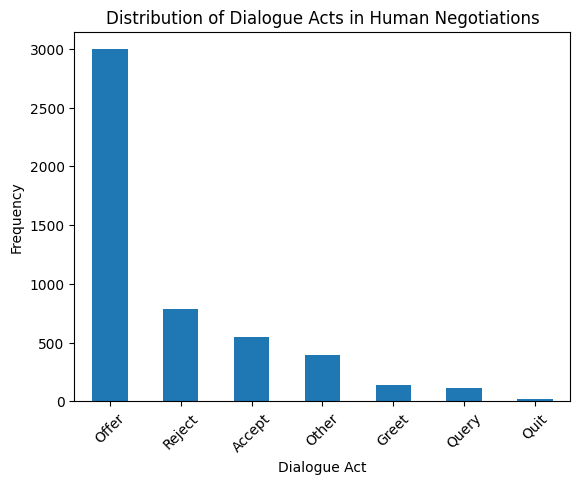

In [20]:
import matplotlib.pyplot as plt

act_counts.plot(kind="bar")

plt.title("Distribution of Dialogue Acts in Human Negotiations")
plt.xlabel("Dialogue Act")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [21]:
role_act_counts = human_df.groupby(["role", "act"]).size().unstack(fill_value=0)
role_act_counts

act,Accept,Greet,Offer,Other,Query,Quit,Reject
role,,,,,,,
Candidate,298,105,1704,284,34,0,542
Employer,249,30,1292,110,79,18,248


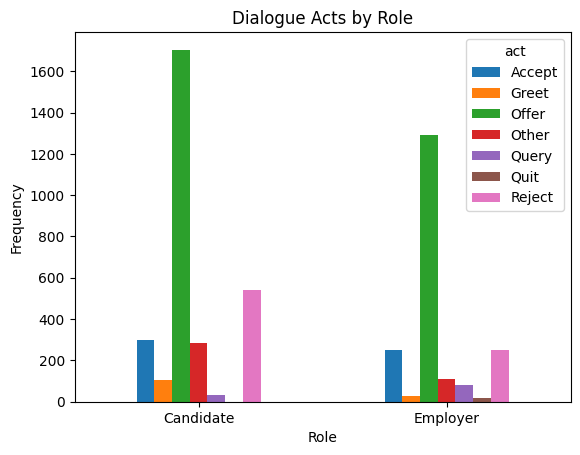

In [22]:
role_act_counts.plot(kind="bar")

plt.title("Dialogue Acts by Role")
plt.xlabel("Role")
plt.ylabel("Frequency")
plt.xticks(rotation=0)
plt.show()

In [23]:
issue_counts = human_df["issue"].value_counts()
issue_counts

issue
Working Hours              865
Salary                     852
Job Description            685
Leased Car                 573
Pension Fund               406
Promotion Possibilities    274
Offer                       64
Name: count, dtype: int64

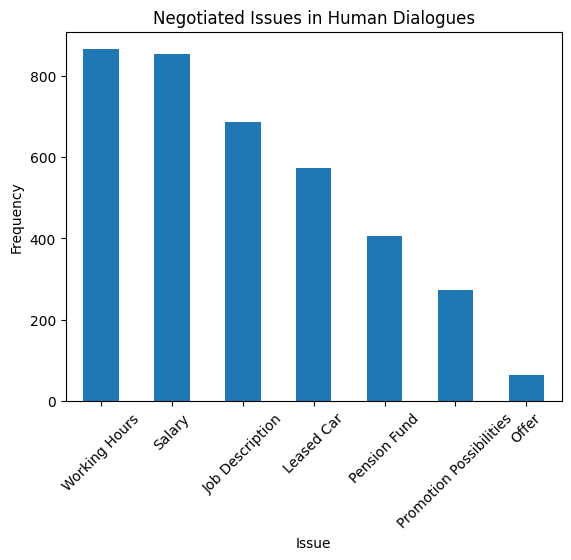

In [24]:
issue_counts.plot(kind="bar")

plt.title("Negotiated Issues in Human Dialogues")
plt.xlabel("Issue")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()

In [25]:
dialogue_lengths = human_df.groupby("dialogue_id")["turn_id"].nunique()

dialogue_lengths.describe()

count    105.000000
mean      34.514286
std       16.407734
min        8.000000
25%       23.000000
50%       30.000000
75%       44.000000
max      103.000000
Name: turn_id, dtype: float64

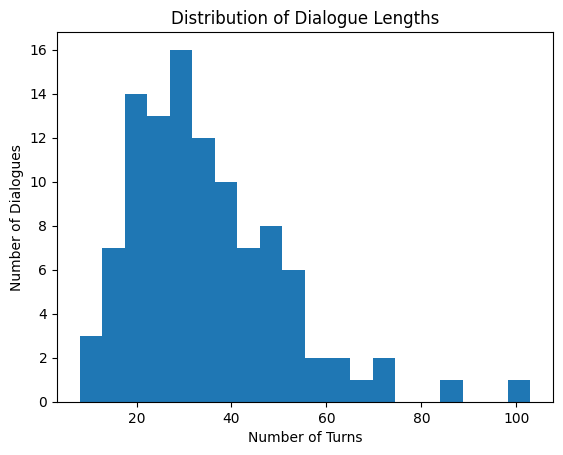

In [26]:
dialogue_lengths.plot(kind="hist", bins=20)

plt.title("Distribution of Dialogue Lengths")
plt.xlabel("Number of Turns")
plt.ylabel("Number of Dialogues")
plt.show()

- dialogue = complete negotiation (0.json) 
- turn = it's once an agent talks; so the time an agent actually talks. for example : Turn 1 → Candidate parla 
--Turn 2 → Employer parla
--Turn 3 → Candidate parla
--Turn 4 → Employer parla
- act = it's the output of the dialogue that can be mnore than one = una mossa negoziale 
The reason why we changed the original dataset is because it was structured based on turns not acts

#In the dataframe the 4993 rows = 4993 acts.

- dialogues = 105 
- turns = 3624 
- acts = 4993 

In [27]:
human_df[["dialogue_id", "turn_id"]].drop_duplicates().shape

(3624, 2)

#### ANALISYS OF HUMAN NEGOTIATION :
Which strategies human mostly use ? 

In [28]:
act_counts = human_df["act"].value_counts()

print(act_counts)

act
Offer     2996
Reject     790
Accept     547
Other      394
Greet      135
Query      113
Quit        18
Name: count, dtype: int64


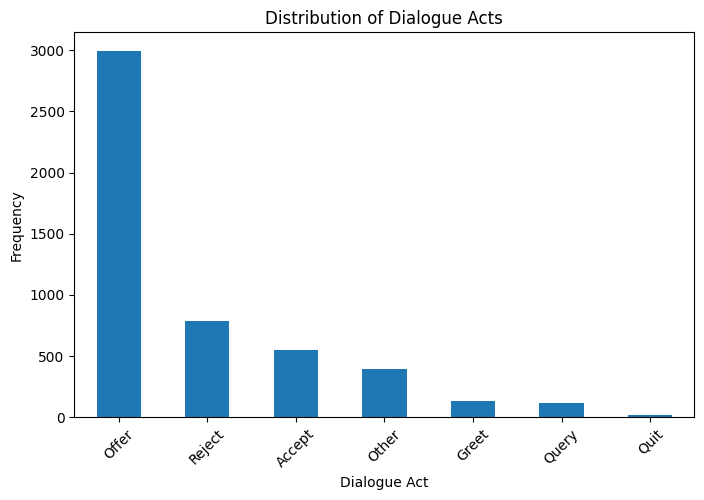

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

act_counts.plot(kind="bar")

plt.title("Distribution of Dialogue Acts")
plt.xlabel("Dialogue Act")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

Human negotiations are highly iterative and rely heavily on counteroffers rather than immediate agreement.

In [30]:
role_act_counts = (
    human_df
    .groupby(["role", "act"])
    .size()
    .unstack(fill_value=0)
)

role_act_counts

act,Accept,Greet,Offer,Other,Query,Quit,Reject
role,,,,,,,
Candidate,298,105,1704,284,34,0,542
Employer,249,30,1292,110,79,18,248


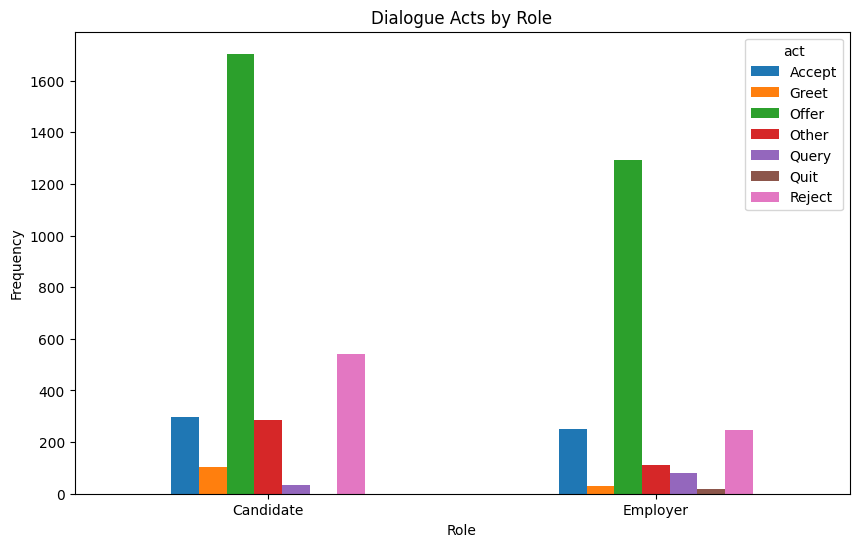

In [31]:
role_act_counts.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Dialogue Acts by Role")
plt.xlabel("Role")
plt.ylabel("Frequency")

plt.xticks(rotation=0)

plt.show()

### Transition analysis 

In [32]:
transitions = []

# ciclo su ogni dialogo
for dialogue_id, group in human_df.groupby("dialogue_id"):

    # ordina per turno
    group = group.sort_values(["turn_id"])

    acts = group["act"].tolist()

    # crea coppie consecutive
    for i in range(len(acts) - 1):

        current_act = acts[i]
        next_act = acts[i + 1]

        transitions.append((current_act, next_act))

In [33]:
transition_df = pd.DataFrame(
    transitions,
    columns=["current_act", "next_act"]
)

transition_df.head()

,current_act,next_act
0,Greet,Offer
1,Offer,Reject
2,Reject,Offer
3,Offer,Offer
4,Offer,Reject


In [34]:
transition_counts = (
    transition_df
    .groupby(["current_act", "next_act"])
    .size()
    .reset_index(name="count")
)

transition_counts.sort_values(
    by="count",
    ascending=False
).head(20)

,current_act,next_act,count
11,Offer,Offer,1524
15,Offer,Reject,743
31,Reject,Offer,671
9,Offer,Accept,516
17,Other,Offer,296
1,Accept,Offer,281
2,Accept,Other,231
5,Greet,Offer,123
12,Offer,Other,108
22,Query,Offer,94


In [35]:
transition_matrix = pd.crosstab(
    transition_df["current_act"],
    transition_df["next_act"]
)

transition_matrix

next_act,Accept,Greet,Offer,Other,Query,Quit,Reject
current_act,,,,,,,
Accept,2,0,281,231,7,0,0
Greet,5,0,123,1,3,0,3
Offer,516,30,1524,108,51,10,743
Other,3,0,296,17,17,1,4
Query,0,0,94,10,2,1,4
Quit,0,0,7,5,2,0,0
Reject,21,0,671,22,31,6,36


A particularly frequent transition is Reject → Offer, suggesting that human negotiators often respond to disagreement with adaptive counteroffers rather than terminating the negotiation. This highlights the iterative and cooperative nature of bargaining dynamics even under conflicting objectives.

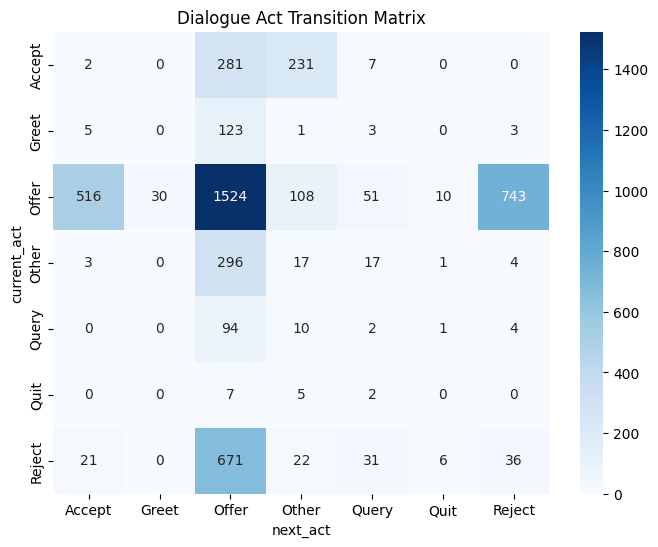

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.heatmap(
    transition_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Dialogue Act Transition Matrix")

plt.show()

Human negotiators frequently respond to rejection with counteroffers, suggesting adaptive bargaining behavior. This transition pattern can later be compared against LLM-based negotiations to evaluate whether artificial agents reproduce similar negotiation dynamics.

Outcome dialogo 

## Agreement Analysis 

In [40]:
dialogue_outcomes = []

for dialogue_id, group in human_df.groupby("dialogue_id"):

    acts = group["act"].tolist()

    has_accept = "Accept" in acts
    has_quit = "Quit" in acts

    if has_quit:
        outcome = "Failure"

    elif has_accept:
        outcome = "Agreement"

    else:
        outcome = "Unresolved"

    dialogue_outcomes.append({
        "dialogue_id": dialogue_id,
        "outcome": outcome
    })

outcome_df = pd.DataFrame(dialogue_outcomes)

outcome_df.head()

,dialogue_id,outcome
0,0,Failure
1,1,Failure
2,10,Agreement
3,100,Failure
4,101,Agreement


In [41]:
outcome_df["outcome"].value_counts()

outcome
Agreement     89
Failure       15
Unresolved     1
Name: count, dtype: int64

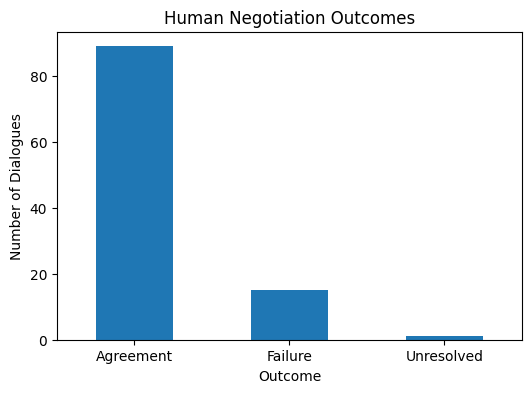

In [42]:
outcome_counts = outcome_df["outcome"].value_counts()

plt.figure(figsize=(6,4))

outcome_counts.plot(kind="bar")

plt.title("Human Negotiation Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Dialogues")

plt.xticks(rotation=0)

plt.show()

#### dialogue length vs outcome 

In [43]:
dialogue_lengths_df = (
    human_df
    .groupby("dialogue_id")["turn_id"]
    .nunique()
    .reset_index(name="n_turns")
)

# merge
outcome_analysis = outcome_df.merge(
    dialogue_lengths_df,
    on="dialogue_id"
)

outcome_analysis.head()

,dialogue_id,outcome,n_turns
0,0,Failure,55
1,1,Failure,27
2,10,Agreement,63
3,100,Failure,43
4,101,Agreement,26


In [44]:
outcome_analysis.groupby("outcome")["n_turns"].mean()

outcome
Agreement     34.955056
Failure       33.133333
Unresolved    16.000000
Name: n_turns, dtype: float64